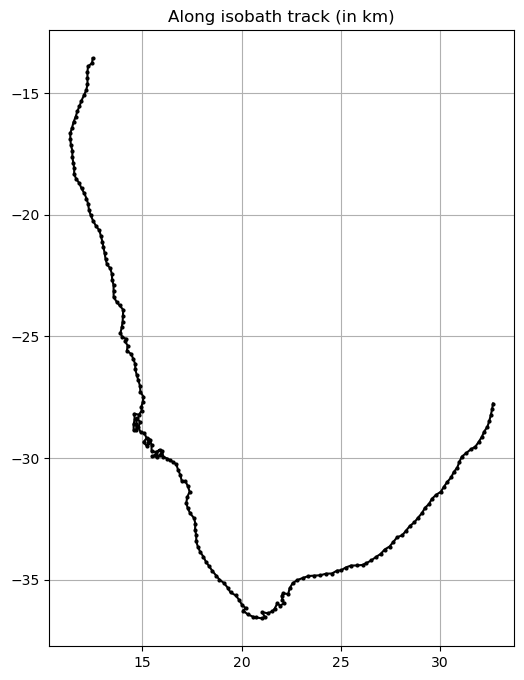

 'Track_isobath.nc' saved with cumulative distance in km.


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from netCDF4 import Dataset

def haversine_dist(lat1, lon1, lat2, lon2):

    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

###################################################################################################################
# Import data and select the region
###################################################################################################################
file_path = '/Users/ABC/Desktop/post_docmercator/GLO-MFC_001_024_mask_bathy.nc'
with Dataset(file_path, 'r') as nc:
    lon_full = nc.variables['longitude'][:]
    lat_full = nc.variables['latitude'][:]
    bathy_full = nc.variables['deptho'][:]

lon_idx = np.where((lon_full >= 0) & (lon_full <= 35))[0]
lat_idx = np.where((lat_full >= -38) & (lat_full <= 0))[0]

longB = lon_full[lon_idx]
latB = lat_full[lat_idx]
Bathy3 = bathy_full[np.ix_(lat_idx, lon_idx)]

###################################################################################################################
# Contour extraction & Cleaning
###################################################################################################################
fig = plt.figure()
cs = plt.contour(longB, latB, Bathy3, levels=[200])
plt.close(fig)

all_paths = cs.get_paths()
coords_brutes = np.vstack([path.vertices for path in all_paths])

# Coupure des sauts (distance > 2 degrés)
dist_points = np.sqrt(np.sum(np.diff(coords_brutes, axis=0)**2, axis=1))
indices_sauts = np.where(dist_points > 2.0)[0]
sous_segments = np.split(coords_brutes, indices_sauts + 1)
coords_fusionnees = max(sous_segments, key=len)

Xcrop, Ycrop = coords_fusionnees[:, 0], coords_fusionnees[:, 1]

###################################################################################################################
# Interpolation basée sur la distance en KM
###################################################################################################################
# Calcul des distances segments en km
dist_segments_km = [haversine_dist(Ycrop[i], Xcrop[i], Ycrop[i+1], Xcrop[i+1]) for i in range(len(Xcrop)-1)]
cumdist_km = np.concatenate(([0], np.cumsum(dist_segments_km)))

# Interpolation
d_interp_km = np.linspace(0, cumdist_km[-1], 200)
f_lon = interp1d(cumdist_km, Xcrop, kind='linear')
f_lat = interp1d(cumdist_km, Ycrop, kind='linear')
lon_final, lat_final = f_lon(d_interp_km), f_lat(d_interp_km)


lon_final = lon_final[::-1]
lat_final = lat_final[::-1]

dist_segments_km = [haversine_dist(lat_final[i], lon_final[i], lat_final[i+1], lon_final[i+1]) 
                    for i in range(len(lon_final)-1)]

d_interp_km = np.concatenate(([0], np.cumsum(dist_segments_km)))
###################################################################################################################
# NetCDF Export 
###################################################################################################################
with Dataset('Track_isobath.nc', 'w', format='NETCDF4') as nc_out:
    nc_out.createDimension('npoints', 200)
    
    v_lon = nc_out.createVariable('lon_final', 'f4', ('npoints',))
    v_lat = nc_out.createVariable('lat_final', 'f4', ('npoints',))
    v_dist = nc_out.createVariable('cumulative_dist_km', 'f4', ('npoints',))
    
    v_lon[:] = lon_final
    v_lat[:] = lat_final
    v_dist[:] = d_interp_km
    
    v_dist.units = 'km'
    v_dist.description = 'Distance cumulative le long de l isobathe en km'

###################################################################################################################
# Plot
###################################################################################################################
plt.figure(figsize=(6, 8))
plt.plot(lon_final, lat_final, 'k-o', markersize=2, label='Track')
plt.title("Along isobath track (in km)")
plt.grid(True)
plt.show()

print(" 'Track_isobath.nc' saved with cumulative distance in km.")

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.signal import butter, filtfilt

###################################################################################################################
#track data
###################################################################################################################

ds_track = xr.open_dataset('/Users/ABC/Desktop/munich/Track_isobath.nc')
lons = ds_track.lon_final.values
lats = ds_track.lat_final.values
dist = ds_track.cumulative_dist_km.values
###################################################################################################################
# MIOST DATA
###################################################################################################################

file_pattern = '/Users/ABC/Desktop/SWOT/calval/dt_global_allsat_phy_l4_*.nc'
files = sorted(glob.glob(file_pattern))

if not files:
    raise FileNotFoundError(f"Aucun fichier trouvé avec le motif : {file_pattern}")

ds = xr.open_mfdataset(files, concat_dim='time', combine='nested')
###################################################################################################################
# ALONG track
###################################################################################################################

track_coords = xr.Dataset(
    {'lon': (('npoints'), lons), 'lat': (('npoints'), lats)},
    coords={'npoints': np.arange(len(lons))}
)

# Extraction et interpolation of SLA

hovmoller_data = ds.sla.interp(longitude=track_coords.lon, latitude=track_coords.lat, method='linear').compute()
hovmoller_data = hovmoller_data.interpolate_na(dim='time', method='linear', limit=5)
###################################################################################################################
# Filter
###################################################################################################################

fc = 1/30 # 1/30 days cuttoff frequency
b, a = butter(4, fc, btype='high', analog=False, fs=1.0)

# Application du filtre sans déphasage
sla_filtered = xr.apply_ufunc(
    lambda x: filtfilt(b, a, x, axis=0),
    hovmoller_data,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask="forbidden"
)
###################################################################################################################
# Hovmöllers
###################################################################################################################

fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)
n_levels=20
cmap1 = plt.cm.get_cmap('RdBu_r', n_levels)
# Plot Brut
im1 = axes[0].pcolormesh(dist, hovmoller_data.time, hovmoller_data.values,
                         cmap=cmap1, shading='auto', vmin=-0.2, vmax=0.2)
axes[0].set_title('Hovmöller - SLA')
axes[0].set_ylabel('Temps')
plt.colorbar(im1, ax=axes[0], label='SLA (m)')

#Filtered SLA
im2 = axes[1].pcolormesh(dist, sla_filtered.time, sla_filtered.values.T,
                         cmap=cmap1, shading='auto', vmin=-0.05, vmax=0.05)
axes[1].set_title('Hovmöller - Filtered SLA (Highpass < 30 days)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Time')
plt.colorbar(im2, ax=axes[1], label='SLA (m)')

plt.tight_layout()
plt.show()

